# Computational Aspects of Ramanujan Summation

In [1]:
# Install and update required packages
import Pkg
Pkg.activate(".")
Pkg.instantiate()

# Add/update required packages
Pkg.add("SymPy")
Pkg.add("Plots")
Pkg.add("Printf")
Pkg.add("SpecialFunctions")
Pkg.update()

  Activating project at `~/Desktop/GIT/Computational-aspects-of-Ramanujan-Summation`
    Updating registry at `~/.julia/registries/General.toml`
   Resolving package versions...
  No Changes to `~/Desktop/GIT/Computational-aspects-of-Ramanujan-Summation/Project.toml`
  No Changes to `~/Desktop/GIT/Computational-aspects-of-Ramanujan-Summation/Manifest.toml`
   Resolving package versions...
  No Changes to `~/Desktop/GIT/Computational-aspects-of-Ramanujan-Summation/Project.toml`
  No Changes to `~/Desktop/GIT/Computational-aspects-of-Ramanujan-Summation/Manifest.toml`
   Resolving package versions...
  No Changes to `~/Desktop/GIT/Computational-aspects-of-Ramanujan-Summation/Project.toml`
  No Changes to `~/Desktop/GIT/Computational-aspects-of-Ramanujan-Summation/Manifest.toml`
   Resolving package versions...
  No Changes to `~/Desktop/GIT/Computational-aspects-of-Ramanujan-Summation/Project.toml`
  No Changes to `~/Desktop/GIT/Computational-aspects-of-Ramanujan-Summation/Manifest.toml`

## Module Definition: Errorplot

The following cell defines the module `Errorplot` which contains all functions needed for computing the infinite series sums using Euler–Maclaurin (for non‐alternating series) and Euler–Boole (for alternating series) tail approximations. Note that we export the symbols `run_example` and `x_` so they can be used directly from the Main module.

In [2]:
module Errorplot

using SymPy
using Plots
using Printf
using SpecialFunctions  # For coth, etc.

export run_example, sum_infinite_series, plot_error_vs_m, x_

##########################################################
# 1) Setup
##########################################################
setprecision(256)  # Very high precision for demonstration
gr()

# Partial-sum cutoffs
const Kset = [1, 2, 3, 4]
# Max correction terms
const m_max = 30

# We'll store Bernoulli / Euler polynomials in caches
const bernoulliCache = Dict{Int, Vector{Rational{BigInt}}}()
const eulerPolyCache = Dict{Tuple{Int, Float64}, Dict{Int, Float64}}()

##########################################################
# 2) Bernoulli numbers (caching)
##########################################################
function BernoulliListCached(n::Int)::Vector{Rational{BigInt}}
    if haskey(bernoulliCache, n)
        return bernoulliCache[n]
    end
    A = Vector{Rational{BigInt}}(undef, n+1)
    B = similar(A)
    for mm in 0:n
        A[mm+1] = 1 // (mm+1)
        for j in mm:-1:1
            A[j] = j*(A[j]-A[j+1])
        end
        B[mm+1] = A[1]
    end
    bernoulliCache[n] = B
    return B
end

##########################################################
# 3) Euler polynomials (for Euler–Boole)
##########################################################
function euler_polynomials_cached(max_n::Int, x_val::Float64)::Dict{Int, Float64}
    key = (max_n, x_val)
    if haskey(eulerPolyCache, key)
        return eulerPolyCache[key]
    end

    t = SymPy.symbols("t")
    expr = (2*SymPy.exp(x_val*t)) / (SymPy.exp(t)+1)
    out = Dict{Int, Float64}()
    for n in 0:max_n
        try
            ser = expr.series(t, 0, n+1).expand()
            coeff_n = factorial(big(n))*ser.coeff(t,n)
            out[n] = float(coeff_n)
        catch
            @warn "Failed Euler poly E_$n($x_val)"
            out[n] = 0.0
        end
    end
    eulerPolyCache[key] = out
    return out
end

##########################################################
# 4) Utility: safe_real_float
##########################################################
function safe_real_float(expr)::Float64
    try
        val = expr.evalf()
        return float(SymPy.real(val))
    catch
        return NaN
    end
end

##########################################################
# 5) Euler–Boole tail approximation (ALTERNATING)
##########################################################
function euler_boole_infinite_tail(f::Sym, m::Int)::Float64
    local x_ = SymPy.symbols("x")
    f1 = safe_real_float(f.subs(x_, 1))

    e_dict = euler_polynomials_cached(m, 1.0)
    sum_corr = 0.0
    for j in 1:m
        d_expr = diff(f, x_, j).subs(x_, 1)
        d_val  = safe_real_float(d_expr)
        e_j    = e_dict[j]
        sum_corr += (e_j / factorial(big(j))) * d_val
    end
    return 0.5*f1 - sum_corr
end

##########################################################
# 6) Euler–Maclaurin tail approximation (NON-ALTERNATING)
##########################################################
function euler_maclaurin_infinite_tail(f::Sym, m::Int)::Float64
    local x_ = SymPy.symbols("x")
    
    integral_sym = try
        SymPy.integrate(f, (x_, 1, SymPy.oo))
    catch
        nothing
    end

    if integral_sym === nothing || integral_sym == SymPy.oo || integral_sym == -SymPy.oo
        integral_val = 0.0
    else
        integral_val = safe_real_float(integral_sym)
    end

    half_term = 0.5 * safe_real_float(f.subs(x_, 1))
    
    Blist = BernoulliListCached(2*m)
    sum_corr = 0.0
    for j in 1:m
        dorder = 2*j - 1
        dexpr  = diff(f, x_, dorder).subs(x_, 1)
        dval   = safe_real_float(dexpr)
        b_2j   = float(Blist[2*j+1])
        denom  = factorial(big(2*j))
        sum_corr += (b_2j / denom) * dval
    end

    return integral_val + half_term - sum_corr
end

##########################################################
# 7) sum_infinite_series = partial sum + tail
##########################################################
function sum_infinite_series(f::Sym, k::Int, m::Int, alt::Bool)::Float64
    local x_ = SymPy.symbols("x")

    S_k = 0.0
    for n in 1:k
        S_k += safe_real_float(f.subs(x_, n))
    end

    f_tail = f.subs(x_, x_ + k)

    if alt
        return S_k + euler_boole_infinite_tail(f_tail, m)
    else
        return S_k + euler_maclaurin_infinite_tail(f_tail, m)
    end
end

##########################################################
# 8) plot_error_vs_m
##########################################################
function plot_error_vs_m(f::Sym, desc::String, known_val::Float64, alt::Bool)
    p = plot(
        title = desc * " : log10(|error|) vs. m",
        xlabel = "m (derivative expansions)",
        ylabel = "log10(|error|)",
        legend = :topright
    )

    for k in Kset
        local logerrs = Float64[]
        println("\n$desc => alt=$alt, k=$k => exact=$known_val")
        # Print Markdown table header
        println("| m | Approx | Error |")
        println("|---|---|---|")
        for mm in 1:m_max
            approx = sum_infinite_series(f, k, mm, alt)
            err = abs(approx - known_val)
            # Print each row in Markdown table format
            @printf("| %2d | %.16e | %.16e |\n", mm, approx, err)
            push!(logerrs, log10(max(err, 1e-300)))
        end
        plot!(p, 1:m_max, logerrs, label="k=$k", linewidth=2)
    end

    # Create the 'plots' directory if it doesn't exist
    if !isdir("plots")
        mkdir("plots")
    end

    # Sanitize the description for a valid filename (replace invalid characters)
    safe_desc = replace(desc, r"[^a-zA-Z0-9\-_\.]" => "")
    # Save the plot to the 'plots' folder
    savefig(p, joinpath("plots", "$(safe_desc).png"))

    display(p)
end

function run_example(f::Sym, desc::String, known_val::Float64, alt::Bool)
    println("\n=== run_example: $desc")
    plot_error_vs_m(f, desc, known_val, alt)
end


# Export x_ for use in Main
const x_ = SymPy.symbols("x")

end # module

Main.Errorplot

In [3]:
# Import the module into Main
using .Errorplot

In [4]:
# Import SymPy into Main so that `Sym` is defined
using SymPy


=== run_example: Harmonic Series

Harmonic Series => alt=false, k=1 => exact=0.57721
| m | Approx | Error |
|---|---|---|
|  1 | 1.2708333333333333e+00 | 6.9362333333333326e-01 |
|  2 | 1.2703125000000000e+00 | 6.9310249999999995e-01 |
|  3 | 1.2703745039682539e+00 | 6.9316450396825391e-01 |
|  4 | 1.2703582279265873e+00 | 6.9314822792658726e-01 |
|  5 | 1.2703656261273448e+00 | 6.9315562612734483e-01 |
|  6 | 1.2703604765189238e+00 | 6.9315047651892381e-01 |
|  7 | 1.2703655627819446e+00 | 6.9315556278194457e-01 |
|  8 | 1.2703587991740968e+00 | 6.9314879917409677e-01 |
|  9 | 1.2703704490853296e+00 | 6.9316044908532959e-01 |
| 10 | 1.2703452184753203e+00 | 6.9313521847532034e-01 |
| 11 | 1.2704123238031477e+00 | 6.9320232380314772e-01 |
| 12 | 1.2701972994185060e+00 | 6.9298729941850601e-01 |
| 13 | 1.2710142940756253e+00 | 6.9380429407562527e-01 |
| 14 | 1.2673823713841215e+00 | 6.9017237138412146e-01 |
| 15 | 1.2860578996614740e+00 | 7.0884789966147399e-01 |
| 16 | 1.1760722268574

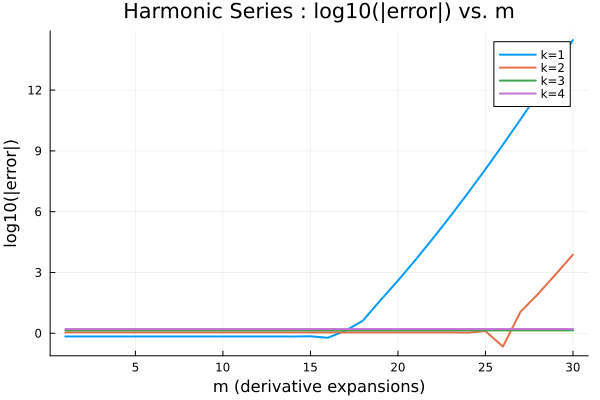

In [5]:
run_example(1 / x_, "Harmonic Series", 0.57721, false)


=== run_example: Basel: sum(1/n²) = π²/6

Basel: sum(1/n²) = π²/6 => alt=false, k=1 => exact=1.6449340668482264
| m | Approx | Error |
|---|---|---|
|  1 | 1.6458333333333335e+00 | 8.9926648510707530e-04 |
|  2 | 1.6447916666666667e+00 | 1.4240018155975420e-04 |
|  3 | 1.6449776785714287e+00 | 4.3611723202330310e-05 |
|  4 | 1.6449125744047619e+00 | 2.1492443464499189e-05 |
|  5 | 1.6449495654085498e+00 | 1.5498560323345956e-05 |
|  6 | 1.6449186677580232e+00 | 1.5399090203205290e-05 |
|  7 | 1.6449542715991692e+00 | 2.0204750942776073e-05 |
|  8 | 1.6449001627363855e+00 | 3.3904111840898921e-05 |
|  9 | 1.6450050119374828e+00 | 7.0945089256424509e-05 |
| 10 | 1.6447527058373890e+00 | 1.8136101083743306e-04 |
| 11 | 1.6454908644434898e+00 | 5.5679759526339190e-04 |
| 12 | 1.6429105718277914e+00 | 2.0234950204349733e-03 |
| 13 | 1.6535315023703399e+00 | 8.5974355221134502e-03 |
| 14 | 1.6026845846892863e+00 | 4.2249482158940088e-02 |
| 15 | 1.8828175088495742e+00 | 2.3788344200134781e-

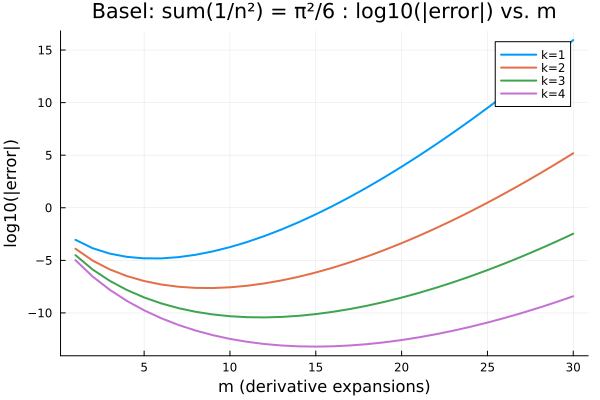

In [6]:
run_example(1/x_^2, "Basel: sum(1/n²) = π²/6", float(pi^2/6), false)


=== run_example: Zeta(3): sum(1/n³) ≈ 1.20206

Zeta(3): sum(1/n³) ≈ 1.20206 => alt=false, k=1 => exact=1.202056903159594
| m | Approx | Error |
|---|---|---|
|  1 | 1.2031250000000000e+00 | 1.0680968404059854e-03 |
|  2 | 1.2018229166666667e+00 | 2.3398649292727391e-04 |
|  3 | 1.2021484375000000e+00 | 9.1534340405985404e-05 |
|  4 | 1.2020019531249999e+00 | 5.4950034594103414e-05 |
|  5 | 1.2021036783854167e+00 | 4.6775225822637267e-05 |
|  6 | 1.2020032610212055e+00 | 5.3642138388543259e-05 |
|  7 | 1.2021367754255023e+00 | 7.9872265908331741e-05 |
|  8 | 1.2019068127586727e+00 | 1.5009040092128778e-04 |
|  9 | 1.2024048464638846e+00 | 3.4794330429055442e-04 |
| 10 | 1.2010802394383913e+00 | 9.7666372120275291e-04 |
| 11 | 1.2053246514234708e+00 | 3.2677482638767685e-03 |
| 12 | 1.1891978225753559e+00 | 1.2859080584238125e-02 |
| 13 | 1.2608891037375582e+00 | 5.8832200577964233e-02 |
| 14 | 8.9224895054992082e-01 | 3.0980795260967320e-01 |
| 15 | 3.0632791127921517e+00 | 1.861222209

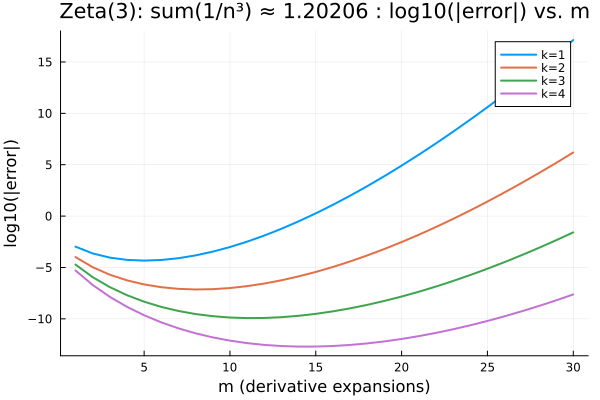

In [7]:
run_example(1/x_^3, "Zeta(3): sum(1/n³) ≈ 1.20206", 1.202056903159594, false)


=== run_example: sum(e⁻ⁿ): 1/(e-1)

sum(e⁻ⁿ): 1/(e-1) => alt=false, k=1 => exact=0.5819767068693265
| m | Approx | Error |
|---|---|---|
|  1 | 5.8216030629607918e-01 | 1.8359942675272301e-04 |
|  2 | 5.8197234062491709e-01 | 4.3662444093595099e-06 |
|  3 | 5.8197681599804008e-01 | 1.0912871362123155e-07 |
|  4 | 5.8197670411371205e-01 | 2.7556144033269447e-09 |
|  5 | 5.8197670693907377e-01 | 6.9747319031421284e-11 |
|  6 | 5.8197670686756009e-01 | 1.7663648321786241e-12 |
|  7 | 5.8197670686937120e-01 | 4.4741987892393809e-14 |
|  8 | 5.8197670686932534e-01 | 1.1102230246251565e-15 |
|  9 | 5.8197670686932645e-01 | 0.0000000000000000e+00 |
| 10 | 5.8197670686932645e-01 | 0.0000000000000000e+00 |
| 11 | 5.8197670686932645e-01 | 0.0000000000000000e+00 |
| 12 | 5.8197670686932645e-01 | 0.0000000000000000e+00 |
| 13 | 5.8197670686932645e-01 | 0.0000000000000000e+00 |
| 14 | 5.8197670686932645e-01 | 0.0000000000000000e+00 |
| 15 | 5.8197670686932645e-01 | 0.0000000000000000e+00 |
| 16 | 

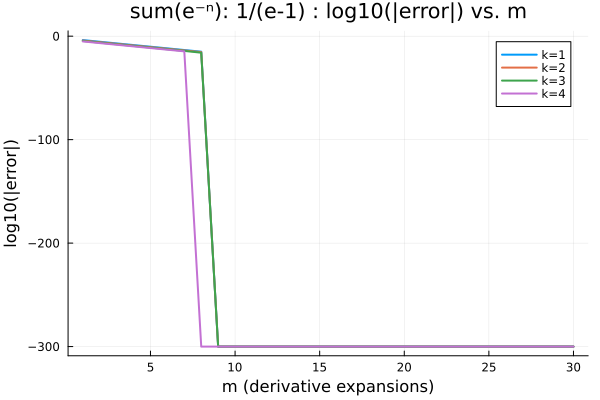

In [8]:
run_example(exp(-x_), "sum(e⁻ⁿ): 1/(e-1)", 1/(exp(1)-1), false)


=== run_example: sum(2⁻ⁿ) = 1

sum(2⁻ⁿ) = 1 => alt=false, k=1 => exact=1.0
| m | Approx | Error |
|---|---|---|
|  1 | 1.0001143264839065e+00 | 1.1432648390652389e-04 |
|  2 | 9.9999869292418797e-01 | 1.3070758120292680e-06 |
|  3 | 1.0000000156978137e+00 | 1.5697813715576103e-08 |
|  4 | 9.9999999980954923e-01 | 1.9045076626866830e-10 |
|  5 | 1.0000000000023159e+00 | 2.3159252293680765e-12 |
|  6 | 9.9999999999997180e-01 | 2.8199664825478976e-14 |
|  7 | 1.0000000000000004e+00 | 4.4408920985006262e-16 |
|  8 | 1.0000000000000000e+00 | 0.0000000000000000e+00 |
|  9 | 1.0000000000000000e+00 | 0.0000000000000000e+00 |
| 10 | 1.0000000000000000e+00 | 0.0000000000000000e+00 |
| 11 | 1.0000000000000000e+00 | 0.0000000000000000e+00 |
| 12 | 1.0000000000000000e+00 | 0.0000000000000000e+00 |
| 13 | 1.0000000000000000e+00 | 0.0000000000000000e+00 |
| 14 | 1.0000000000000000e+00 | 0.0000000000000000e+00 |
| 15 | 1.0000000000000000e+00 | 0.0000000000000000e+00 |
| 16 | 1.0000000000000000e+00 | 

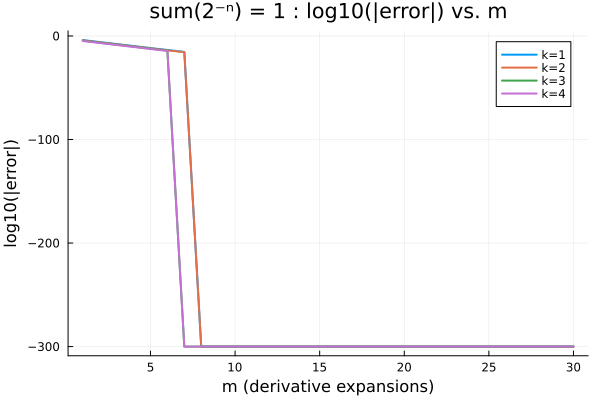

In [9]:
run_example((Sym(2))^(-x_), "sum(2⁻ⁿ) = 1", 1.0, false)


=== run_example: sum(1/(n+1)²) = ζ(2)-1

sum(1/(n+1)²) = ζ(2)-1 => alt=false, k=1 => exact=0.6449340668482264
| m | Approx | Error |
|---|---|---|
|  1 | 6.4506172839506171e-01 | 1.2766154683530040e-04 |
|  2 | 6.4492455418381334e-01 | 9.5126644130694160e-06 |
|  3 | 6.4493544102597600e-01 | 1.3741777495912544e-06 |
|  4 | 6.4493374751719512e-01 | 3.1933103128434226e-07 |
|  5 | 6.4493417517092766e-01 | 1.0832270125327170e-07 |
|  6 | 6.4493401641165926e-01 | 5.0436567144984679e-08 |
|  7 | 6.4493409771866517e-01 | 3.0870438760821628e-08 |
|  8 | 6.4493404280037558e-01 | 2.4047850821773409e-08 |
|  9 | 6.4493409009711522e-01 | 2.3248888814109137e-08 |
| 10 | 6.4493403951333161e-01 | 2.7334894792119258e-08 |
| 11 | 6.4493410528679784e-01 | 3.8438571436927305e-08 |
| 12 | 6.4493400310171922e-01 | 6.3746507183992662e-08 |
| 13 | 6.4493419004014207e-01 | 1.2319191566856347e-07 |
| 14 | 6.4493379228287895e-01 | 2.7456534745784467e-07 |
| 15 | 6.4493476622942980e-01 | 6.9938120339507748e-07

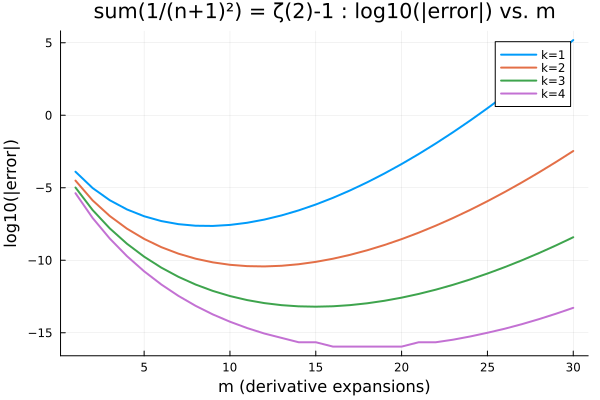

In [10]:
run_example(1/(x_+1)^2, "sum(1/(n+1)²) = ζ(2)-1", float(pi^2/6 - 1.0), false)


=== run_example: sum(1/[n(n+1)]) = 1

sum(1/[n(n+1)]) = 1 => alt=false, k=1 => exact=1.0
| m | Approx | Error |
|---|---|---|
|  1 | 1.0003725155155718e+00 | 3.7251551557182516e-04 |
|  2 | 9.9995456284067463e-01 | 4.5437159325367737e-05 |
|  3 | 1.0000111233878473e+00 | 1.1123387847256083e-05 |
|  4 | 9.9999548241197345e-01 | 4.5175880265535540e-06 |
|  5 | 1.0000027523166113e+00 | 2.7523166112874975e-06 |
|  6 | 9.9999764239800726e-01 | 2.3576019927418201e-06 |
|  7 | 1.0000027112380985e+00 | 2.7112380984739559e-06 |
|  8 | 9.9999595792742968e-01 | 4.0420725703205207e-06 |
|  9 | 1.0000075999558726e+00 | 7.5999558726280725e-06 |
| 10 | 9.9998237693343084e-01 | 1.7623066569161239e-05 |
| 11 | 1.0000494732921492e+00 | 4.9473292149215808e-05 |
| 12 | 9.9983446168064249e-01 | 1.6553831935750551e-04 |
| 13 | 1.0006514347679436e+00 | 6.5143476794360389e-04 |
| 14 | 9.9701955469328940e-01 | 2.9804453067105996e-03 |
| 15 | 1.0156949855759869e+00 | 1.5694985575986919e-02 |
| 16 | 9.057095676

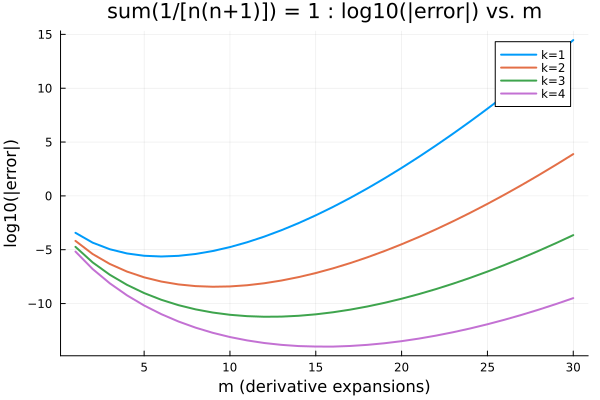

In [11]:
run_example(1/(x_*(x_+1)), "sum(1/[n(n+1)]) = 1", 1.0, false)


=== run_example: sum[(-1)^(n+1)/n] = ln2

sum[(-1)^(n+1)/n] = ln2 => alt=true, k=1 => exact=0.6931471805599453
| m | Approx | Error |
|---|---|---|
|  1 | 6.2500000000000000e-01 | 6.8147180559945286e-02 |
|  2 | 6.2500000000000000e-01 | 6.8147180559945286e-02 |
|  3 | 3.3219986246595745e-01 | 3.6094731809398783e-01 |
|  4 | 3.3219986246595745e-01 | 3.6094731809398783e-01 |
|  5 | -2.8739084569117335e-02 | 7.2188626512906262e-01 |
|  6 | -2.8739084569117335e-02 | 7.2188626512906262e-01 |
|  7 | -3.5459979929835095e-01 | 1.0477469798582963e+00 |
|  8 | -3.5459979929835073e-01 | 1.0477469798582959e+00 |
|  9 | -6.7228939449163594e-01 | 1.3654365750515813e+00 |
| 10 | -6.7228939449163594e-01 | 1.3654365750515813e+00 |
| 11 | -9.0164907172625552e-01 | 1.5947962522862009e+00 |
| 12 | -9.0164907172625508e-01 | 1.5947962522862005e+00 |
| 13 | -1.3125054891127346e+00 | 2.0056526696726800e+00 |
| 14 | -1.3125054891127346e+00 | 2.0056526696726800e+00 |
| 15 | -6.4682961344916512e-01 | 1.33997679

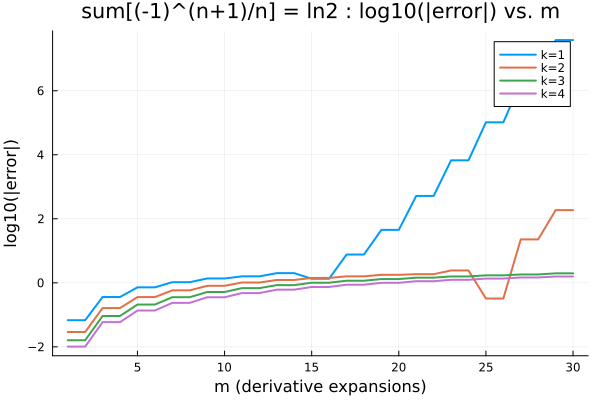

In [12]:
run_example(-cos(pi*x_)/x_, "sum[(-1)^(n+1)/n] = ln2", log(2), true)


=== run_example: sum[(-1)^(n+1)/n²] = π²/12

sum[(-1)^(n+1)/n²] = π²/12 => alt=true, k=1 => exact=0.8224670334241132
| m | Approx | Error |
|---|---|---|
|  1 | 7.5000000000000000e-01 | 7.2467033424113203e-02 |
|  2 | 7.5000000000000000e-01 | 7.2467033424113203e-02 |
|  3 | 4.7282486246595745e-01 | 3.4964217095815575e-01 |
|  4 | 4.7282486246595745e-01 | 3.4964217095815575e-01 |
|  5 | 2.5047348419790394e-01 | 5.7199354922620926e-01 |
|  6 | 2.5047348419790394e-01 | 5.7199354922620926e-01 |
|  7 | 1.6086110887847715e-01 | 6.6160592454563605e-01 |
|  8 | 1.6086110887847715e-01 | 6.6160592454563605e-01 |
|  9 | 6.5823157382643993e-03 | 8.1588471768584880e-01 |
| 10 | 6.5823157382643993e-03 | 8.1588471768584880e-01 |
| 11 | 2.0708814680964072e-01 | 6.1537888661447249e-01 |
| 12 | 2.0708814680964160e-01 | 6.1537888661447160e-01 |
| 13 | -9.9607097931836308e-01 | 1.8185380127424762e+00 |
| 14 | -9.9607097931836086e-01 | 1.8185380127424740e+00 |
| 15 | 6.0696428113085892e+00 | 5.24717577788

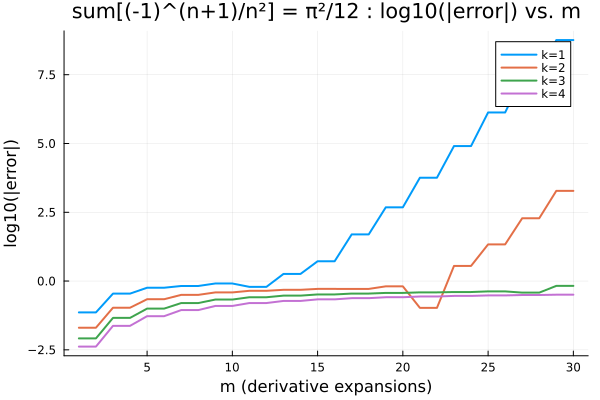

In [13]:
run_example(-cos(pi*x_)/x_^2, "sum[(-1)^(n+1)/n²] = π²/12", float(pi^2/12), true)


=== run_example: sum[(-1)^(n+1)/n³] ≈ 0.90154

sum[(-1)^(n+1)/n³] ≈ 0.90154 => alt=true, k=1 => exact=0.9015426773696955
| m | Approx | Error |
|---|---|---|
|  1 | 8.4375000000000000e-01 | 5.7792677369695511e-02 |
|  2 | 8.4375000000000000e-01 | 5.7792677369695511e-02 |
|  3 | 6.5149364684946809e-01 | 2.5004903052022742e-01 |
|  4 | 6.5149364684946809e-01 | 2.5004903052022742e-01 |
|  5 | 6.1550518191544912e-01 | 2.8603749545424639e-01 |
|  6 | 6.1550518191544912e-01 | 2.8603749545424639e-01 |
|  7 | 6.4559572927072595e-01 | 2.5594694809896956e-01 |
|  8 | 6.4559572927072595e-01 | 2.5594694809896956e-01 |
|  9 | 5.1586833681038868e-01 | 3.8567434055930683e-01 |
| 10 | 5.1586833681038868e-01 | 3.8567434055930683e-01 |
| 11 | 1.1351722653762792e+00 | 2.3362958800658373e-01 |
| 12 | 1.1351722653762817e+00 | 2.3362958800658618e-01 |
| 13 | -2.4124643294140276e+00 | 3.3140070067837231e+00 |
| 14 | -2.4124643294140204e+00 | 3.3140070067837160e+00 |
| 15 | 2.3357990775341726e+01 | 2.2456448

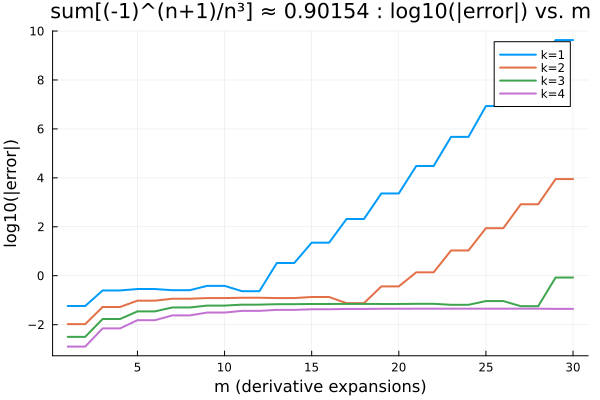

In [14]:
run_example(-cos(pi*x_)/x_^3, "sum[(-1)^(n+1)/n³] ≈ 0.90154", 0.9015426773696955, true)


=== run_example: Catalan: ≈ 0.91597

Catalan: ≈ 0.91597 => alt=true, k=1 => exact=0.915965594177219
| m | Approx | Error |
|---|---|---|
|  1 | -7.5111111111111101e-02 | 9.9107670528833014e-01 |
|  2 | -7.5111111111111101e-02 | 9.9107670528833014e-01 |
|  3 | -3.8192693506753667e-02 | 9.5415828768397271e-01 |
|  4 | -3.8192693506753667e-02 | 9.5415828768397271e-01 |
|  5 | 2.7093132491258637e-03 | 9.1325628092809319e-01 |
|  6 | 2.7093132491258637e-03 | 9.1325628092809319e-01 |
|  7 | 2.9847004672533595e-02 | 8.8611858950468547e-01 |
|  8 | 2.9847004672533595e-02 | 8.8611858950468547e-01 |
|  9 | 5.0768600317265739e-02 | 8.6519699385995330e-01 |
| 10 | 5.0768600317265739e-02 | 8.6519699385995330e-01 |
| 11 | 6.2336189600950775e-02 | 8.5362940457626824e-01 |
| 12 | 6.2336189600950803e-02 | 8.5362940457626824e-01 |
| 13 | 7.8075716716045518e-02 | 8.3788987746117349e-01 |
| 14 | 7.8075716716045490e-02 | 8.3788987746117349e-01 |
| 15 | 6.5852929982854164e-02 | 8.5011266419436482e-01 |
| 1

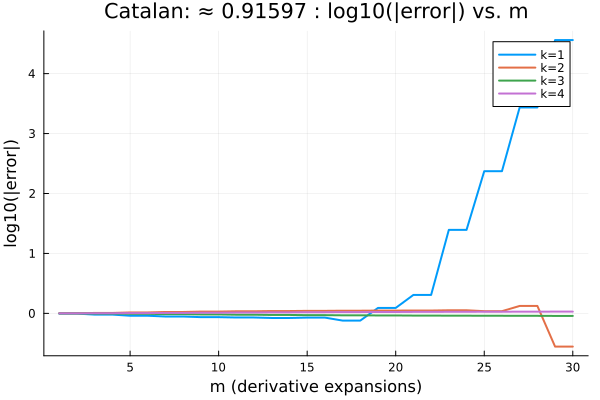

In [15]:
run_example((((-1)^x_)*(1/(2*x_+1)^2)), "Catalan: ≈ 0.91597", 0.915965594177219, true)


=== run_example: Arctan(1): π/4

Arctan(1): π/4 => alt=true, k=1 => exact=0.7853981633974483
| m | Approx | Error |
|---|---|---|
|  1 | 7.2222222222222221e-01 | 6.3175941175226069e-02 |
|  2 | 7.2222222222222221e-01 | 6.3175941175226069e-02 |
|  3 | 4.7275790243887583e-01 | 3.1264026095857245e-01 |
|  4 | 4.7275790243887583e-01 | 3.1264026095857245e-01 |
|  5 | 2.4353595042220955e-01 | 5.4186221297523873e-01 |
|  6 | 2.4353595042220955e-01 | 5.4186221297523873e-01 |
|  7 | 4.5969996716800909e-02 | 7.3942816668064737e-01 |
|  8 | 4.5969996716801020e-02 | 7.3942816668064726e-01 |
|  9 | -1.2413803701688564e-01 | 9.0953620041433392e-01 |
| 10 | -1.2413803701688564e-01 | 9.0953620041433392e-01 |
| 11 | -2.7222193527061567e-01 | 1.0576200986680639e+00 |
| 12 | -2.7222193527061567e-01 | 1.0576200986680639e+00 |
| 13 | -4.0276667203159477e-01 | 1.1881648354290431e+00 |
| 14 | -4.0276667203159477e-01 | 1.1881648354290431e+00 |
| 15 | -5.1920097190157555e-01 | 1.3045991352990238e+00 |
| 16 | 

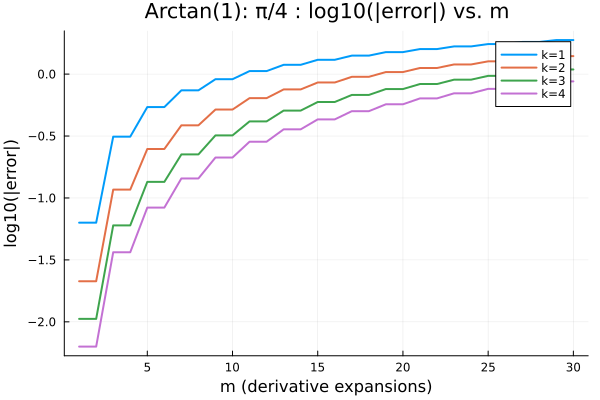

In [16]:
run_example(cos(pi*(x_-1))/(2*x_ - 1), "Arctan(1): π/4", float(pi/4), true)


=== run_example: sum[(-1)^n/√n] ≈ -0.60490

sum[(-1)^n/√n] ≈ -0.60490 => alt=true, k=1 => exact=-0.6048986434
| m | Approx | Error |
|---|---|---|
|  1 | -5.5805826175840778e-01 | 4.6840381641592210e-02 |
|  2 | -5.5805826175840778e-01 | 4.6840381641592210e-02 |
|  3 | -3.4687409517971757e-01 | 2.5802454822028242e-01 |
|  4 | -3.4687409517971757e-01 | 2.5802454822028242e-01 |
|  5 | -5.3565229954010252e-02 | 5.5133341344598974e-01 |
|  6 | -5.3565229954010252e-02 | 5.5133341344598974e-01 |
|  7 | 2.6436504005542982e-01 | 8.6926368345542981e-01 |
|  8 | 2.6436504005542938e-01 | 8.6926368345542937e-01 |
|  9 | 5.9507253009576289e-01 | 1.1999711734957628e+00 |
| 10 | 5.9507253009576289e-01 | 1.1999711734957628e+00 |
| 11 | 9.1160151846194615e-01 | 1.5165001618619462e+00 |
| 12 | 9.1160151846194526e-01 | 1.5165001618619454e+00 |
| 13 | 1.2646512046950384e+00 | 1.8695498480950383e+00 |
| 14 | 1.2646512046950389e+00 | 1.8695498480950388e+00 |
| 15 | 1.4069504158934478e+00 | 2.01184905929344

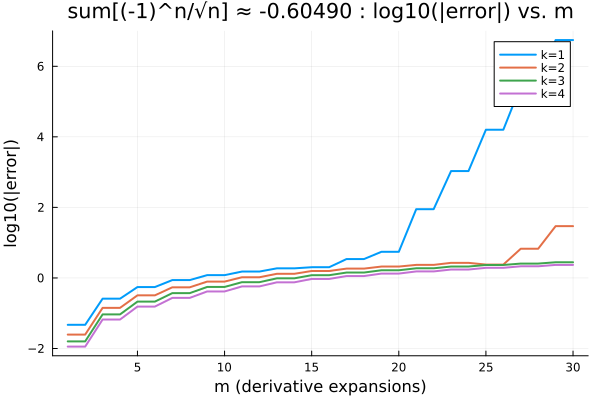

In [17]:
run_example(cos(pi*x_)/sqrt(x_), "sum[(-1)^n/√n] ≈ -0.60490", -0.6048986434, true)


=== run_example: Leibniz series = pi/4

Leibniz series = pi/4 => alt=true, k=1 => exact=0.785398
| m | Approx | Error |
|---|---|---|
|  1 | -1.9333333333333330e-01 | 9.7873133333333340e-01 |
|  2 | -1.9333333333333330e-01 | 9.7873133333333340e-01 |
|  3 | -9.7837289322439708e-02 | 8.8323528932243978e-01 |
|  4 | -9.7837289322439708e-02 | 8.8323528932243978e-01 |
|  5 | 3.3952461650745058e-02 | 7.5144553834925498e-01 |
|  6 | 3.3952461650745058e-02 | 7.5144553834925498e-01 |
|  7 | 1.7133010169425961e-01 | 6.1406789830574038e-01 |
|  8 | 1.7133010169425950e-01 | 6.1406789830574060e-01 |
|  9 | 3.0281229637085599e-01 | 4.8258570362914405e-01 |
| 10 | 3.0281229637085599e-01 | 4.8258570362914405e-01 |
| 11 | 4.2500109274464876e-01 | 3.6039690725535128e-01 |
| 12 | 4.2500109274464853e-01 | 3.6039690725535151e-01 |
| 13 | 5.3748519861134825e-01 | 2.4791280138865179e-01 |
| 14 | 5.3748519861134825e-01 | 2.4791280138865179e-01 |
| 15 | 6.4088699831244278e-01 | 1.4451100168755726e-01 |
| 16 |

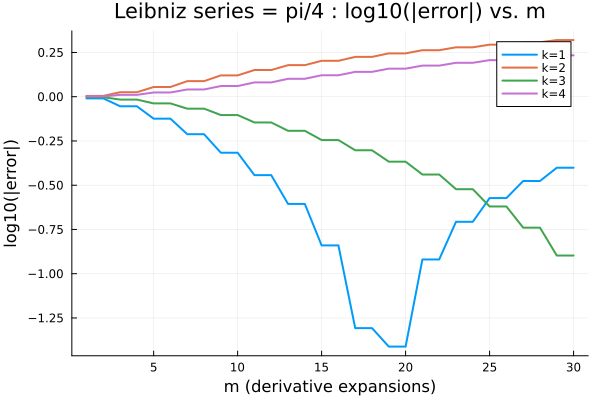

In [18]:
run_example(((-1)^x_)*(1/(2*x_+1)), "Leibniz series = pi/4", 0.785398, true)


=== run_example: C(1; 0) = -0.5

C(1; 0) = -0.5 => alt=false, k=1 => exact=-0.5
| m | Approx | Error |
|---|---|---|
|  1 | 1.5000000000000000e+00 | 2.0000000000000000e+00 |
|  2 | 1.5000000000000000e+00 | 2.0000000000000000e+00 |
|  3 | 1.5000000000000000e+00 | 2.0000000000000000e+00 |
|  4 | 1.5000000000000000e+00 | 2.0000000000000000e+00 |
|  5 | 1.5000000000000000e+00 | 2.0000000000000000e+00 |
|  6 | 1.5000000000000000e+00 | 2.0000000000000000e+00 |
|  7 | 1.5000000000000000e+00 | 2.0000000000000000e+00 |
|  8 | 1.5000000000000000e+00 | 2.0000000000000000e+00 |
|  9 | 1.5000000000000000e+00 | 2.0000000000000000e+00 |
| 10 | 1.5000000000000000e+00 | 2.0000000000000000e+00 |
| 11 | 1.5000000000000000e+00 | 2.0000000000000000e+00 |
| 12 | 1.5000000000000000e+00 | 2.0000000000000000e+00 |
| 13 | 1.5000000000000000e+00 | 2.0000000000000000e+00 |
| 14 | 1.5000000000000000e+00 | 2.0000000000000000e+00 |
| 15 | 1.5000000000000000e+00 | 2.0000000000000000e+00 |
| 16 | 1.5000000000000000e+

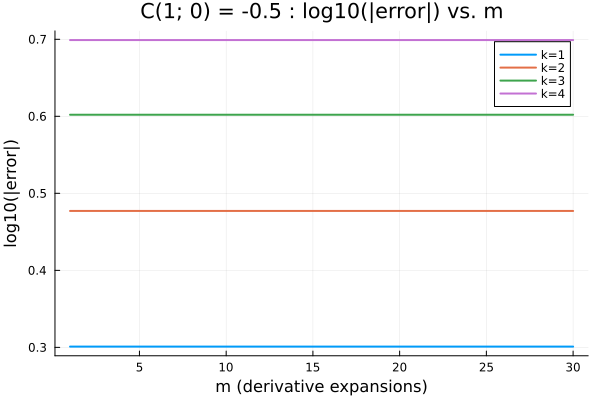

In [19]:
run_example(Sym(1), "C(1; 0) = -0.5", -0.5, false)


=== run_example: C(n; 0) = -1/12

C(n; 0) = -1/12 => alt=false, k=1 => exact=-0.08333333333333333
| m | Approx | Error |
|---|---|---|
|  1 | 1.9166666666666665e+00 | 1.9999999999999998e+00 |
|  2 | 1.9166666666666665e+00 | 1.9999999999999998e+00 |
|  3 | 1.9166666666666665e+00 | 1.9999999999999998e+00 |
|  4 | 1.9166666666666665e+00 | 1.9999999999999998e+00 |
|  5 | 1.9166666666666665e+00 | 1.9999999999999998e+00 |
|  6 | 1.9166666666666665e+00 | 1.9999999999999998e+00 |
|  7 | 1.9166666666666665e+00 | 1.9999999999999998e+00 |
|  8 | 1.9166666666666665e+00 | 1.9999999999999998e+00 |
|  9 | 1.9166666666666665e+00 | 1.9999999999999998e+00 |
| 10 | 1.9166666666666665e+00 | 1.9999999999999998e+00 |
| 11 | 1.9166666666666665e+00 | 1.9999999999999998e+00 |
| 12 | 1.9166666666666665e+00 | 1.9999999999999998e+00 |
| 13 | 1.9166666666666665e+00 | 1.9999999999999998e+00 |
| 14 | 1.9166666666666665e+00 | 1.9999999999999998e+00 |
| 15 | 1.9166666666666665e+00 | 1.9999999999999998e+00 |
| 16 | 1.

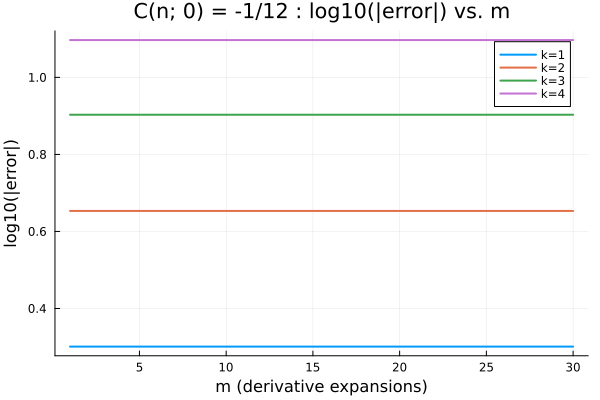

In [20]:
run_example(x_, "C(n; 0) = -1/12", -1/12, false)


=== run_example: C((-1)^{n-1}; 0) = 0.5

C((-1)^{n-1}; 0) = 0.5 => alt=true, k=1 => exact=0.5
| m | Approx | Error |
|---|---|---|
|  1 | 5.0000000000000000e-01 | 0.0000000000000000e+00 |
|  2 | 5.0000000000000000e-01 | 0.0000000000000000e+00 |
|  3 | 5.0000000000000000e-01 | 0.0000000000000000e+00 |
|  4 | 5.0000000000000000e-01 | 0.0000000000000000e+00 |
|  5 | 5.0000000000000000e-01 | 0.0000000000000000e+00 |
|  6 | 5.0000000000000000e-01 | 0.0000000000000000e+00 |
|  7 | 5.0000000000000000e-01 | 0.0000000000000000e+00 |
|  8 | 5.0000000000000111e-01 | 1.1102230246251565e-15 |
|  9 | 5.0000000000000111e-01 | 1.1102230246251565e-15 |
| 10 | 5.0000000000000111e-01 | 1.1102230246251565e-15 |
| 11 | 5.0000000000000111e-01 | 1.1102230246251565e-15 |
| 12 | 5.0000000000000333e-01 | 3.3306690738754696e-15 |
| 13 | 5.0000000000000333e-01 | 3.3306690738754696e-15 |
| 14 | 5.0000000000000244e-01 | 2.4424906541753444e-15 |
| 15 | 5.0000000000000244e-01 | 2.4424906541753444e-15 |
| 16 | 5.0000

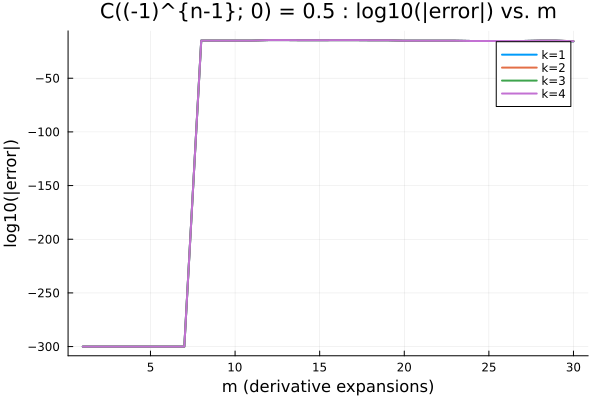

In [21]:
run_example((-1)^(x_-1), "C((-1)^{n-1}; 0) = 0.5", 0.5, true)


=== run_example: C((-1)^{n-1}n; 0) = 0.25

C((-1)^{n-1}n; 0) = 0.25 => alt=true, k=1 => exact=0.25
| m | Approx | Error |
|---|---|---|
|  1 | 5.0000000000000000e-01 | 2.5000000000000000e-01 |
|  2 | 5.0000000000000000e-01 | 2.5000000000000000e-01 |
|  3 | 1.7337005501361702e+00 | 1.4837005501361702e+00 |
|  4 | 1.7337005501361702e+00 | 1.4837005501361702e+00 |
|  5 | 3.7630566133445540e+00 | 3.5130566133445540e+00 |
|  6 | 3.7630566133445540e+00 | 3.5130566133445540e+00 |
|  7 | 6.6004899971605564e+00 | 6.3504899971605564e+00 |
|  8 | 6.6004899971605591e+00 | 6.3504899971605591e+00 |
|  9 | 1.0248114767723404e+01 | 9.9981147677234041e+00 |
| 10 | 1.0248114767723404e+01 | 9.9981147677234041e+00 |
| 11 | 1.4706255255348335e+01 | 1.4456255255348335e+01 |
| 12 | 1.4706255255348340e+01 | 1.4456255255348340e+01 |
| 13 | 1.9974957907175764e+01 | 1.9724957907175764e+01 |
| 14 | 1.9974957907175760e+01 | 1.9724957907175760e+01 |
| 15 | 2.6054229066981001e+01 | 2.5804229066981001e+01 |
| 16 | 2

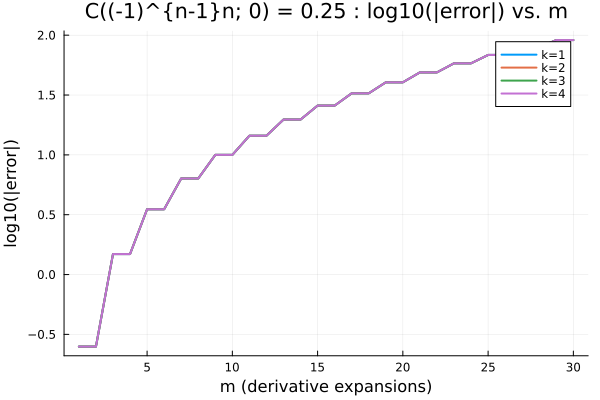

In [22]:
run_example(((-1)^(x_-1))*x_, "C((-1)^{n-1}n; 0) = 0.25", 0.25, true)

# Referencing from the paper by Chagas: Illustrative examples to compute Ramanujan constants using the formula for Ramanujan constant of series (RCS) or Euler Maclaurin constant of f as coined by Hardy.

In [23]:
# 10) Ramanujan constant for a general series
function ramanujan_constant(f::Sym, n_terms::Int)::Float64
    integral_val = Errorplot.safe_real_float(-SymPy.integrate(f, (Errorplot.x_, 0, 1)))
    f1_val = Errorplot.safe_real_float(f.subs(Errorplot.x_, 1)) / 2
    B = Errorplot.BernoulliListCached(2 * n_terms)
    sum_term = 0.0
    for k in 1:n_terms
        d_val = Errorplot.safe_real_float(diff(f, Errorplot.x_, 2*k - 1).subs(Errorplot.x_, 1))
        b_val = float(B[2*k+1])
        sum_term += b_val / float(factorial(2*k)) * d_val
    end
    return integral_val + f1_val - sum_term
end


# 12) Ramanujan constant for binary series
function ramanujan_constant_binary_series(base::BigFloat, n_terms::Int)::BigFloat
    log2 = log(base)
    log4 = log(BigFloat(4))
    
    integral_term = -1 / log4
    f1_term = BigFloat(1) / 4
    sum_term = BigFloat(0)
    
    B = Errorplot.BernoulliListCached(2 * n_terms)
    for k in 1:n_terms
        b_val = BigFloat(B[2*k+1])
        denom = BigFloat(factorial(2*k))
        # (log2)^(2*k-1) is computed with high-precision BigFloat arithmetic
        sum_term += b_val / denom * (log2^(2*k - 1)) / 2
    end
    
    return integral_term + f1_term + sum_term
end

# 13) Ramanujan constant for exponential series
function ramanujan_constant_exponential(base::Sym, offset::Int, n_terms::Int)::Float64
    # Define f(x) = base^(x + offset - 1)
    f = base^(Errorplot.x_ + offset - 1)
    
    integral_val = Errorplot.safe_real_float(-SymPy.integrate(f, (Errorplot.x_, 0, 1)))
    f1_val = Errorplot.safe_real_float(f.subs(Errorplot.x_, 1)) / 2
    
    B = Errorplot.BernoulliListCached(2 * n_terms)
    sum_term = 0.0
    for k in 1:n_terms
        # For this exponential f, the derivative at x = 1 is always 1.
        b_val = float(B[2*k+1])
        sum_term += b_val / float(factorial(2*k))
    end
    
    return integral_val + f1_val - sum_term
end

# 14) Ramanujan constant for Euler-type series
#     (accepting a vector of derivative functions)
function ramanujan_constant_euler(f::Function, derivatives::Vector{Function}, max_terms::Int=10)::Float64
    # f is a function (e.g. f(x)=1 or f(x)=x) taking a Float64 and returning a Float64.
    f1 = f(1.0)
    e_dict = Errorplot.euler_polynomials_cached(max_terms, 1.0)
    sum_term = 0.0
    for k in 1:max_terms
        d_val = derivatives[k](1.0)
        sum_term += e_dict[k] / factorial(k) * d_val
    end
    return f1 / 2 - sum_term / 2
end


ramanujan_constant_euler (generic function with 2 methods)

In [24]:
# Example: Ramanujan constant for a general series using f(x) = x^2
# (Also loop over f(x)=x^n for n = 1 to 10)

# Use the global symbol x_ from the module
f_general = x_^2
println("Ramanujan constant for f(x)=x^2: ", ramanujan_constant(f_general, 10))

println("\nn\tRamanujan constant for f(x)=x^n")
for n in 1:10
    f_power = x_^n
    rc = ramanujan_constant(f_power, 10)
    println("$(n)\t$(rc)")
end


Ramanujan constant for f(x)=x^2: 1.850371707708594e-17

n	Ramanujan constant for f(x)=x^n
1	-0.08333333333333333
2	1.850371707708594e-17
3	0.008333333333333333
4	-1.1102230246251566e-17
5	-0.003968253968253932
6	7.93016446160826e-18
7	0.004166666666666667
8	6.1679056923619804e-18
9	-0.007575757575757553
10	-3.027880976250427e-17


In [25]:

using SymPy

# f(x) = -1 
f_alt1 = Sym(-1)
println("Ramanujan constant f(x) = -1: ", ramanujan_constant(f_alt1, 10))

# f(x) = -x (linear alternating function)
f_alt2 = -x_
println("Ramanujan constant f(x) = -x: ", ramanujan_constant(f_alt2, 10))

# f(x) = -x^3 (cubic alternating function)
f_alt3 = -x_^3
println("Ramanujan constant f(x) = -x^3: ", ramanujan_constant(f_alt3, 10))

# f(x) = -exp(x) (exponential alternating function)
f_alt4 = -exp(x_)
println("Ramanujan constant f(x) = -exp(x): ", ramanujan_constant(f_alt4, 10))

# f(x) = -2^(-x) (binary alternating function)
f_alt5 = -2^(-x_)
println("Ramanujan constant f(x) = -2^(-x): ", ramanujan_constant(f_alt5, 10))


Ramanujan constant f(x) = -1: 0.5
Ramanujan constant f(x) = -x: 0.08333333333333333
Ramanujan constant f(x) = -x^3: -0.008333333333333333
Ramanujan constant f(x) = -exp(x): 0.5819767068693266
Ramanujan constant f(x) = -2^(-x): 0.4426950408889634


In [26]:
# Example: Ramanujan constant for binary series
# Here we use BigFloat arithmetic for high-precision computation.
base_binary = BigFloat(2.0)
rc_binary = ramanujan_constant_binary_series(base_binary, 10)
println("Ramanujan constant for binary series (C(2^-n;0)) = ", rc_binary)
println("Ramanujan constant for binary series (rounded) = ", round(rc_binary, digits=10))


Ramanujan constant for binary series (C(2^-n;0)) = -0.4426950408889634073611609819841176758014401477298813902337679860020094358929399
Ramanujan constant for binary series (rounded) = -0.4426950409000000000000000000000000000000000000000000000000000000000000000000003


In [27]:
# Example: Ramanujan constant for exponential series
# Define e as a symbolic constant using SymPy.
E_sym = Sym(exp(1))

# Using offset 0: f(x) = e^(x-1)
offset1 = 0
rc_expo1 = ramanujan_constant_exponential(E_sym, offset1, 10)
println("Ramanujan constant for exponential series f(x)=e^(x-1): ", rc_expo1)

# Using offset 1: f(x) = e^x
offset2 = 1
rc_expo2 = ramanujan_constant_exponential(E_sym, offset2, 10)
println("Ramanujan constant for exponential series f(x)=e^x: ", rc_expo2)


Ramanujan constant for exponential series f(x)=e^(x-1): -0.2140972656978841
Ramanujan constant for exponential series f(x)=e^x: -0.44111762109884894


In [28]:
using SymPy
using SpecialFunctions
# Define the function f(x, α) symbolically
function f(x, α)
    return gamma(α + 1) / (gamma(x) * gamma(α - x + 2))
end

# Compute symbolic derivatives of f at x = 1
function compute_derivatives(α, max_order)
    x = symbols("x")  # Define the symbolic variable
    f_x = gamma(α + 1) / (gamma(x) * gamma(α - x + 2))  # Define f(x, α) symbolically

    # Compute derivatives of f at x = 1 and substitute x = 1 after each differentiation
    derivatives = [SymPy.diff(f_x, x, n).subs(Dict(x => 1)) for n in 1:max_order]
    return [N(deriv) for deriv in derivatives]  # Convert symbolic derivatives to numerical values
end

# Precomputed Euler polynomials E_k(1) / k! for k = 1, 3, 5 as used in the paper
euler_polys_at_1 = [1//2, -1//24, 1//240]  # E_1(1), E_3(1), and E_5(1)

# Compute the Ramanujan constant C(f) for a given α
function ramanujan_constant(α, max_order)
    f1 = f(1, α) / 2  # f(1)/2
    derivatives = compute_derivatives(α, max_order)  # Compute derivatives at x = 1

    # Calculate the sum of the terms in the Ramanujan constant formula up to max_order (using odd derivatives only)
    sum_term = sum(euler_polys_at_1[(k + 1) ÷ 2] * derivatives[k] for k in 1:2:max_order)
    return f1 - sum_term / 2
end

# Define the range of α values (from 1.0 down to -1.0, stepping by -0.1)
alphas = 1.0:-0.1:-1.0

# Set the maximum order of derivatives to compute (odd orders only: 1, 3, 5)
max_order = 5

# Print the Markdown table header
println("| α | C(f) | fhalf | f'(1) | f'''(1) | f^(5)(1) |")
println("|---|------|-------|-------|---------|----------|")

# Generate the table rows
for α in alphas
    C_f = ramanujan_constant(α, max_order)
    fhalf = f(1, α) / 2
    derivatives = compute_derivatives(α, max_order)
    f1_prime = derivatives[1]
    f3_prime = max_order >= 3 ? derivatives[3] : "N/A"
    f5_prime = max_order >= 5 ? derivatives[5] : "N/A"
    println("| $(α) | $(C_f) | $(fhalf) | $(f1_prime) | $(f3_prime) | $(f5_prime) |")
end


| α | C(f) | fhalf | f'(1) | f'''(1) | f^(5)(1) |
|---|------|-------|-------|---------|----------|
| 1.0 | 0.12768115203518987 | 0.5 | 1.0 | -3.8696044010893584 | 20.017003012215266 |
| 0.9 | 0.14600461011504667 | 0.5 | 0.9333998260655925 | -3.7735907095807613 | 20.173900921098888 |
| 0.8 | 0.1667495743196461 | 0.5 | 0.8622070981953944 | -3.6398806970874595 | 20.09654557224793 |
| 0.7 | 0.1903225224833306 | 0.5 | 0.785763539775027 | -3.462293697172905 | 19.730627463269023 |
| 0.6 | 0.21722518754867637 | 0.5 | 0.7032631176750092 | -3.233214142245562 | 19.008194433178648 |
| 0.5 | 0.24808489044222598 | 0.5 | 0.6137056388801094 | -2.9431361355960757 | 17.84321456615764 |
| 0.4 | 0.2836975015082749 | 0.5 | 0.5158311203164166 | -2.580018636898574 | 16.125278469072338 |
| 0.3 | 0.32508971245105656 | 0.5 | 0.40802477603473297 | -2.128351096624178 | 13.710453933083112 |
| 0.2 | 0.37361171004463034 | 0.5 | 0.2881757683093449 | -1.5677632879673673 | 10.407654101782397 |
| 0.1 | 0.43107933901103

In [29]:
using SymPy
using Printf
using SpecialFunctions  # for factorial
using .Errorplot       # make sure Errorplot is accessible in this environment

"""
Compute the Ramanujan constant for an ALTERNATING series with general term f(n),
using the Euler–Boole style approach. We rely on your Errorplot module's 
'euler_polynomials_cached' function to retrieve E_k(1).

Arguments:
  - f:            a Julia function of one real argument x
  - derivatives:  a Vector{Function} of the 1st, 2nd, etc. derivatives
  - max_terms:    how many terms in the Euler expansion to sum
Returns:
  - Float64, the approximate Ramanujan constant for the alternating series
"""
function ramanujan_constant_alternating(f::Function, derivatives::Vector{Function}, max_terms::Int=10)::Float64
    # Evaluate f(1)
    f1 = f(1.0)

    # Retrieve E_k(1) up to 'max_terms'
    e_dict = Errorplot.euler_polynomials_cached(max_terms, 1.0)

    # Sum up correction terms
    sum_term = 0.0
    for k in 1:max_terms
        d_val = derivatives[k](1.0)          # k-th derivative at x=1
        E_k1 = e_dict[k]                    # Euler polynomial E_k(1)
        sum_term += (E_k1 / factorial(k)) * d_val
    end

    # Ramanujan constant for an alternating series
    return f1/2 - sum_term/2
end

"""
Example for Grandi's series: 1 - 1 + 1 - 1 + ...
We treat f(x)=1.0, so all derivatives are 0.
"""
function example_grandis()
    f_grandi(x) = 1.0
    # Construct as Vector{Function} so it matches the method signature
    derivatives_grandi = Vector{Function}([ x->0.0 for _ in 1:10 ])
    C_grandi = ramanujan_constant_alternating(f_grandi, derivatives_grandi, 10)
    @printf("Ramanujan constant for Grandi’s series = %.8f\n", C_grandi)
end

"""
Example for Euler's alternating series: 1 - 2 + 3 - 4 + ...
We define f(x)=x, so the first derivative at x=1 is 1, higher derivatives are 0.
"""
function example_euler_alternating()
    f_euler(x) = x
    # Again ensure we have Vector{Function}
    derivatives_euler = Vector{Function}([ x->1.0 ])  # 1st derivative
    append!(derivatives_euler, Vector{Function}([ x->0.0 for _ in 2:10 ]))

    C_euler = ramanujan_constant_alternating(f_euler, derivatives_euler, 10)
    @printf("Ramanujan constant for Euler’s alternating series = %.8f\n", C_euler)
end

# --- Run the examples directly:
example_grandis()
example_euler_alternating()


Ramanujan constant for Grandi’s series = 0.50000000
Ramanujan constant for Euler’s alternating series = 0.25000000
